In [2]:
import os
import numpy as np
import pandas as pd
import math
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib

In [3]:
# Tạo thư mục lưu kết quả và model
output_dir = '../../../'  # This points to the parent folder
if not os.path.exists(output_dir):
    os.makedirs(output_dir, exist_ok=True)

output_dir_result = os.path.join(output_dir, 'Result/AAPL/ARIMA/')
if not os.path.exists(output_dir_result):
    os.makedirs(output_dir_result, exist_ok=True)

output_dir_models = os.path.join(output_dir, 'Models/AAPL/ARIMA/')
if not os.path.exists(output_dir_models):
    os.makedirs(output_dir_models, exist_ok=True)

In [4]:
# Đường dẫn tới tệp CSV
file_path = '../../../Data/AAPL.csv'

# Đọc CSV, bỏ qua 2 hàng đầu (Ticker và Date NaN)
df = pd.read_csv(file_path, skiprows=2)

# Đặt tên cột thủ công (dựa trên cấu trúc file)
df.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

# Chuyển Date thành datetime và set làm index
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')  # Format ngày tháng kiểu YYYY-MM-DD
df.set_index('Date', inplace=True)

# Kiểm tra DataFrame sau xử lý (tùy chọn)
print(df.head())  # Nên hiển thị dữ liệu từ 2014-09-17
print(df.tail())  # Kiểm tra ngày cuối
df.info()  # Xem số hàng và kiểu dữ liệu

               Close      High       Low      Open     Volume
Date                                                         
1980-12-12  0.098597  0.099025  0.098597  0.098597  469033600
1980-12-15  0.093453  0.093881  0.093453  0.093881  175884800
1980-12-16  0.086594  0.087022  0.086594  0.087022  105728000
1980-12-17  0.088737  0.089165  0.088737  0.088737   86441600
1980-12-18  0.091309  0.091738  0.091309  0.091309   73449600
                 Close        High         Low        Open    Volume
Date                                                                
2025-07-17  210.020004  211.800003  209.589996  210.570007  48068100
2025-07-18  211.179993  211.789993  209.699997  210.869995  48974600
2025-07-21  212.479996  215.779999  211.630005  212.100006  51377400
2025-07-22  214.399994  214.949997  212.229996  213.139999  46404100
2025-07-23  214.149994  215.149994  212.410004  215.000000  46913800
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 11243 entries, 1980-12-12 to 2

In [5]:
# Thực hiện seasonal decomposition
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Sử dụng Close price cho decomposition
close_prices = df['Close'].copy()

# Seasonal decomposition với different methods
def perform_seasonal_decomposition(data, period=252):  # 252 trading days = 1 year
    """
    Thực hiện seasonal decomposition
    period=252: Chu kỳ 1 năm (252 ngày giao dịch)
    """
    
    # Additive decomposition
    decomposition_add = seasonal_decompose(
        data, 
        model='additive', 
        period=period,
        extrapolate_trend='freq'  # Xử lý missing values ở đầu/cuối
    )
    
    # Multiplicative decomposition  
    decomposition_mult = seasonal_decompose(
        data, 
        model='multiplicative', 
        period=period,
        extrapolate_trend='freq'
    )
    
    return decomposition_add, decomposition_mult

# Thực hiện decomposition
decomp_add, decomp_mult = perform_seasonal_decomposition(close_prices)


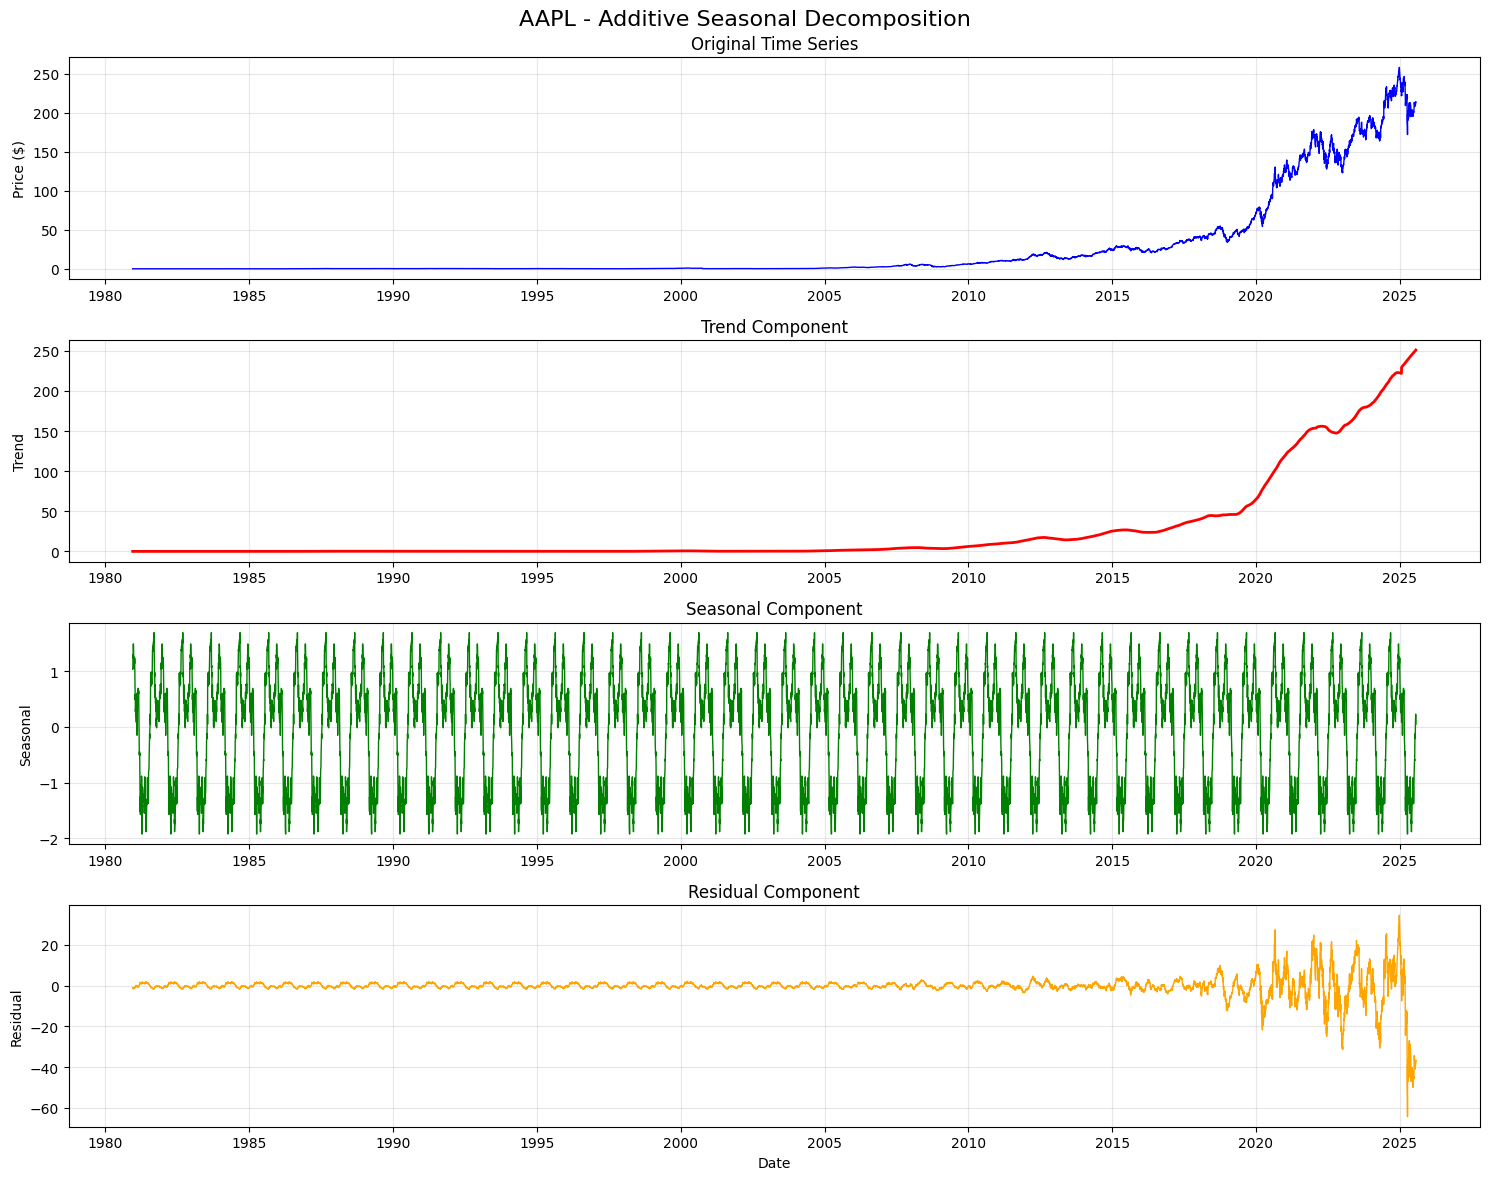

In [6]:
# Plot Additive Decomposition
fig, axes = plt.subplots(4, 1, figsize=(15, 12))
fig.suptitle('AAPL - Additive Seasonal Decomposition', fontsize=16, y=0.98)

# Original data
axes[0].plot(decomp_add.observed, color='blue', linewidth=1)
axes[0].set_title('Original Time Series')
axes[0].set_ylabel('Price ($)')
axes[0].grid(True, alpha=0.3)

# Trend
axes[1].plot(decomp_add.trend, color='red', linewidth=2)
axes[1].set_title('Trend Component')
axes[1].set_ylabel('Trend')
axes[1].grid(True, alpha=0.3)

# Seasonal
axes[2].plot(decomp_add.seasonal, color='green', linewidth=1)
axes[2].set_title('Seasonal Component')
axes[2].set_ylabel('Seasonal')
axes[2].grid(True, alpha=0.3)

# Residual
axes[3].plot(decomp_add.resid, color='orange', linewidth=1)
axes[3].set_title('Residual Component')
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Date')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir_result, 'seasonal_decomposition_additive.png'), 
            dpi=300, bbox_inches='tight')
plt.show()


In [7]:
# Tạo interactive plot với Plotly
def create_interactive_decomposition(decomp, title_suffix=""):
    fig = make_subplots(
        rows=4, cols=1,
        subplot_titles=('Original Time Series', 'Trend', 'Seasonal', 'Residual'),
        vertical_spacing=0.08,
        shared_xaxes=True
    )
    
    # Original
    fig.add_trace(
        go.Scatter(
            x=decomp.observed.index,
            y=decomp.observed.values,
            mode='lines',
            name='Original',
            line=dict(color='blue', width=1)
        ),
        row=1, col=1
    )
    
    # Trend
    fig.add_trace(
        go.Scatter(
            x=decomp.trend.index,
            y=decomp.trend.values,
            mode='lines',
            name='Trend',
            line=dict(color='red', width=2)
        ),
        row=2, col=1
    )
    
    # Seasonal
    fig.add_trace(
        go.Scatter(
            x=decomp.seasonal.index,
            y=decomp.seasonal.values,
            mode='lines',
            name='Seasonal',
            line=dict(color='green', width=1)
        ),
        row=3, col=1
    )
    
    # Residual
    fig.add_trace(
        go.Scatter(
            x=decomp.resid.index,
            y=decomp.resid.values,
            mode='lines',
            name='Residual',
            line=dict(color='orange', width=1)
        ),
        row=4, col=1
    )
    
    fig.update_layout(
        height=800,
        title_text=f'AAPL - Seasonal Decomposition {title_suffix}',
        showlegend=False
    )
    
    fig.update_xaxes(title_text="Date", row=4, col=1)
    fig.update_yaxes(title_text="Price ($)", row=1, col=1)
    fig.update_yaxes(title_text="Trend", row=2, col=1)
    fig.update_yaxes(title_text="Seasonal", row=3, col=1)
    fig.update_yaxes(title_text="Residual", row=4, col=1)
    
    return fig

# Tạo plots
fig_add = create_interactive_decomposition(decomp_add, "(Additive)")
fig_mult = create_interactive_decomposition(decomp_mult, "(Multiplicative)")

# Save HTML files
fig_add.write_html(os.path.join(output_dir_result, 'seasonal_decomposition_additive.html'))
fig_mult.write_html(os.path.join(output_dir_result, 'seasonal_decomposition_multiplicative.html'))

fig_add.show()
fig_mult.show()


In [8]:
# Phân tích statistical properties của từng component
def analyze_decomposition_components(decomp, model_name):
    print(f"\n{'='*50}")
    print(f"PHÂN TÍCH {model_name.upper()} DECOMPOSITION")
    print(f"{'='*50}")
    
    components = {
        'Original': decomp.observed,
        'Trend': decomp.trend,
        'Seasonal': decomp.seasonal, 
        'Residual': decomp.resid
    }
    
    stats_df = pd.DataFrame()
    
    for name, component in components.items():
        # Bỏ qua NaN values
        clean_data = component.dropna()
        
        stats = {
            'Mean': clean_data.mean(),
            'Std': clean_data.std(),
            'Min': clean_data.min(),
            'Max': clean_data.max(),
            'Skewness': clean_data.skew(),
            'Kurtosis': clean_data.kurtosis()
        }
        
        stats_df[name] = stats
    
    print(stats_df.round(4))
    
    # Seasonal pattern analysis
    print(f"\\n📊 SEASONAL PATTERN ANALYSIS:")
    seasonal_clean = decomp.seasonal.dropna()
    
    # Tìm seasonal peaks và troughs
    seasonal_by_month = seasonal_clean.groupby(seasonal_clean.index.month).mean()
    
    print(f"Strongest positive seasonal effect: Month {seasonal_by_month.idxmax()} ({seasonal_by_month.max():.4f})")
    print(f"Strongest negative seasonal effect: Month {seasonal_by_month.idxmin()} ({seasonal_by_month.min():.4f})")
    
    return stats_df, seasonal_by_month

# Phân tích cả hai models
stats_add, seasonal_monthly_add = analyze_decomposition_components(decomp_add, "Additive")
stats_mult, seasonal_monthly_mult = analyze_decomposition_components(decomp_mult, "Multiplicative")



PHÂN TÍCH ADDITIVE DECOMPOSITION
          Original     Trend  Seasonal  Residual
Mean       25.7862   26.0396   -0.0063   -0.2472
Std        53.6481   54.2665    0.9836    5.2834
Min         0.0377    0.0575   -1.9213  -64.3117
Max       258.3967  250.9303    1.6911   34.5895
Skewness    2.4319    2.4476   -0.2747   -3.0911
Kurtosis    4.8585    4.9768   -1.2439   29.6317
\n📊 SEASONAL PATTERN ANALYSIS:
Strongest positive seasonal effect: Month 8 (1.2980)
Strongest negative seasonal effect: Month 5 (-1.4032)

PHÂN TÍCH MULTIPLICATIVE DECOMPOSITION
          Original     Trend  Seasonal  Residual
Mean       25.7862   26.0396    1.0001    0.9895
Std        53.6481   54.2665    0.0182    0.1342
Min         0.0377    0.0575    0.9504    0.4694
Max       258.3967  250.9303    1.0450    1.6486
Skewness    2.4319    2.4476    0.0301    0.1129
Kurtosis    4.8585    4.9768   -0.0446    1.1794
\n📊 SEASONAL PATTERN ANALYSIS:
Strongest positive seasonal effect: Month 5 (1.0323)
Strongest negative

In [9]:
# Phân tích seasonal patterns chi tiết hơn
def detailed_seasonal_analysis(data):
    df_analysis = pd.DataFrame({
        'Price': data,
        'Month': data.index.month,
        'Quarter': data.index.quarter,
        'Year': data.index.year,
        'DayOfYear': data.index.dayofyear
    })
    
    # Monthly seasonality
    monthly_stats = df_analysis.groupby('Month')['Price'].agg([
        'mean', 'std', 'min', 'max', 'count'
    ]).round(2)
    
    # Quarterly seasonality  
    quarterly_stats = df_analysis.groupby('Quarter')['Price'].agg([
        'mean', 'std', 'min', 'max', 'count'
    ]).round(2)
    
    print("\\n📅 MONTHLY SEASONALITY:")
    print(monthly_stats)
    
    print("\\n📅 QUARTERLY SEASONALITY:")
    print(quarterly_stats)
    
    # Plot monthly boxplot
    fig = go.Figure()
    
    for month in range(1, 13):
        month_data = df_analysis[df_analysis['Month'] == month]['Price']
        fig.add_trace(go.Box(
            y=month_data,
            name=f'Month {month}',
            boxpoints='outliers'
        ))
    
    fig.update_layout(
        title='AAPL Monthly Price Distribution',
        xaxis_title='Month',
        yaxis_title='Price ($)',
        height=500
    )
    
    fig.write_html(os.path.join(output_dir_result, 'monthly_seasonality_boxplot.html'))
    fig.show()
    
    return monthly_stats, quarterly_stats

# Thực hiện phân tích
monthly_stats, quarterly_stats = detailed_seasonal_analysis(close_prices)


\n📅 MONTHLY SEASONALITY:
        mean    std   min     max  count
Month                                   
1      25.25  54.10  0.06  244.41    927
2      26.32  55.45  0.06  246.78    863
3      25.37  52.49  0.05  238.76    985
4      25.57  51.93  0.05  223.60    930
5      26.15  52.89  0.05  213.04    951
6      26.01  53.40  0.04  215.66    959
7      27.35  56.84  0.04  233.73    946
8      25.38  53.13  0.04  228.99    975
9      25.13  52.11  0.05  232.18    894
10     24.99  52.08  0.05  235.65    971
11     25.72  53.21  0.06  236.76    900
12     26.25  56.28  0.06  258.40    942
\n📅 QUARTERLY SEASONALITY:
          mean    std   min     max  count
Quarter                                   
1        25.62  53.95  0.05  246.78   2775
2        25.91  52.73  0.04  223.60   2840
3        25.96  54.08  0.04  233.73   2815
4        25.65  53.86  0.05  258.40   2813


\n🔍 RESIDUAL ANALYSIS:
Mean: -0.247216
Std: 5.2834
Skewness: -3.0911
Kurtosis: 29.6317
\nLjung-Box Test (lag 10): p-value = 0.0000
⚠️ Residuals may have remaining autocorrelation


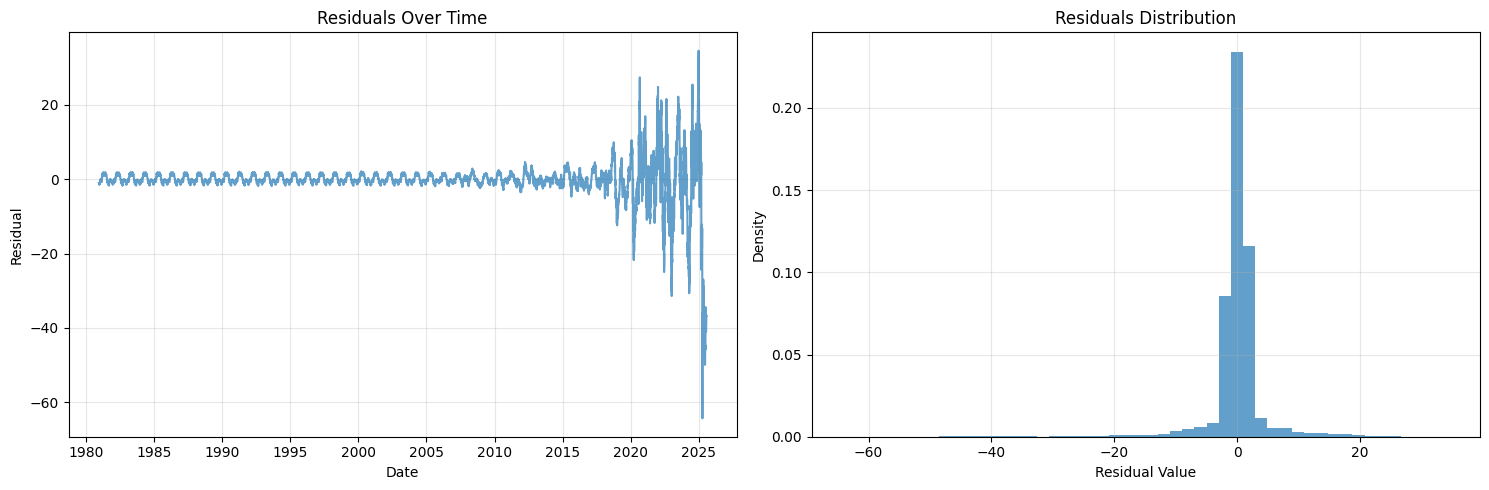

\n🔍 RESIDUAL ANALYSIS:
Mean: 0.989491
Std: 0.1342
Skewness: 0.1129
Kurtosis: 1.1794
\nLjung-Box Test (lag 10): p-value = 0.0000
⚠️ Residuals may have remaining autocorrelation


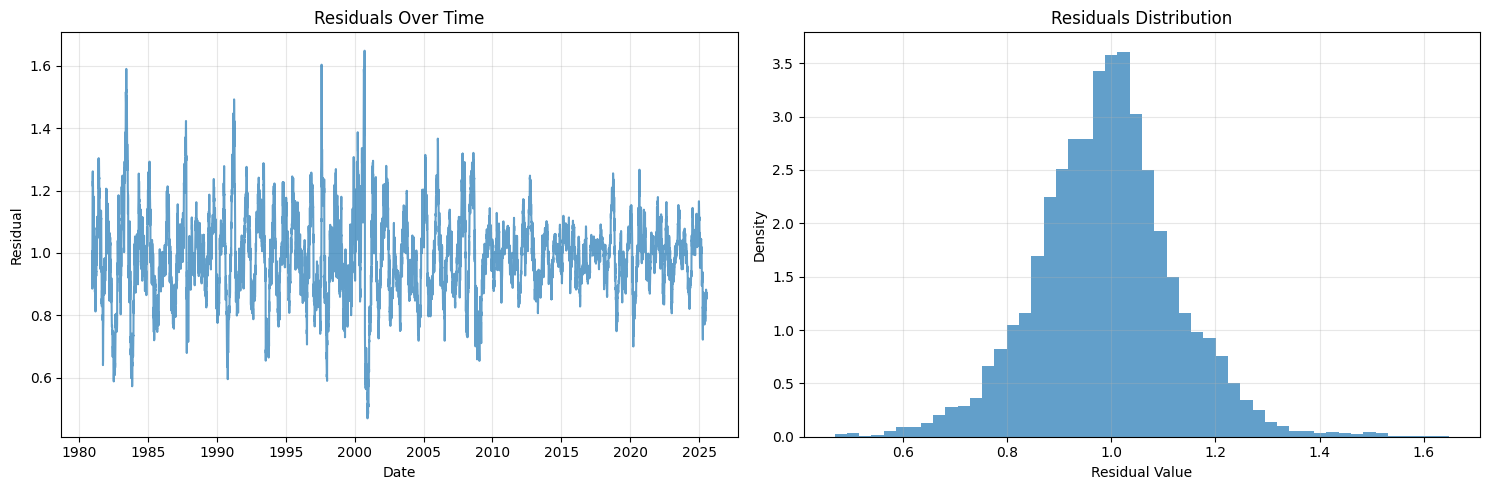

In [10]:
# Phân tích residuals để kiểm tra quality của decomposition
def analyze_residuals(residuals):
    print("\\n🔍 RESIDUAL ANALYSIS:")
    
    # Remove NaN values
    clean_residuals = residuals.dropna()
    
    # Basic stats
    print(f"Mean: {clean_residuals.mean():.6f}")
    print(f"Std: {clean_residuals.std():.4f}")
    print(f"Skewness: {clean_residuals.skew():.4f}")
    print(f"Kurtosis: {clean_residuals.kurtosis():.4f}")
    
    # Test for randomness (Ljung-Box test)
    from statsmodels.stats.diagnostic import acorr_ljungbox
    lb_test = acorr_ljungbox(clean_residuals, lags=20, return_df=True)
    
    print(f"\\nLjung-Box Test (lag 10): p-value = {lb_test.loc[10, 'lb_pvalue']:.4f}")
    if lb_test.loc[10, 'lb_pvalue'] > 0.05:
        print("✅ Residuals appear to be random (good!)")
    else:
        print("⚠️ Residuals may have remaining autocorrelation")
    
    # Plot residuals
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Time series plot
    ax1.plot(clean_residuals.index, clean_residuals.values, alpha=0.7)
    ax1.set_title('Residuals Over Time')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Residual')
    ax1.grid(True, alpha=0.3)
    
    # Histogram
    ax2.hist(clean_residuals.values, bins=50, alpha=0.7, density=True)
    ax2.set_title('Residuals Distribution')
    ax2.set_xlabel('Residual Value')
    ax2.set_ylabel('Density')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir_result, 'residuals_analysis.png'), dpi=300, bbox_inches='tight')
    plt.show()

# Phân tích residuals
analyze_residuals(decomp_add.resid)
analyze_residuals(decomp_mult.resid)


In [11]:
# So sánh hiệu quả của hai models
def compare_decomposition_models(decomp_add, decomp_mult):
    print("\\n⚖️ COMPARISON: ADDITIVE vs MULTIPLICATIVE")
    print("="*50)
    
    # Calculate reconstruction error
    def reconstruction_error(original, trend, seasonal, residual, model_type):
        if model_type == 'additive':
            reconstructed = trend + seasonal + residual
        else:  # multiplicative
            reconstructed = trend * seasonal * residual
        
        # Remove NaN values for comparison
        mask = ~(original.isna() | reconstructed.isna())
        original_clean = original[mask]
        reconstructed_clean = reconstructed[mask]
        
        mse = mean_squared_error(original_clean, reconstructed_clean)
        mae = mean_absolute_error(original_clean, reconstructed_clean)
        
        return mse, mae, np.corrcoef(original_clean, reconstructed_clean)[0,1]
    
    # Calculate errors
    mse_add, mae_add, corr_add = reconstruction_error(
        decomp_add.observed, decomp_add.trend, decomp_add.seasonal, decomp_add.resid, 'additive'
    )
    
    mse_mult, mae_mult, corr_mult = reconstruction_error(
        decomp_mult.observed, decomp_mult.trend, decomp_mult.seasonal, decomp_mult.resid, 'multiplicative'
    )
    
    comparison_df = pd.DataFrame({
        'Additive': [mse_add, mae_add, corr_add],
        'Multiplicative': [mse_mult, mae_mult, corr_mult]
    }, index=['MSE', 'MAE', 'Correlation'])
    
    print(comparison_df.round(6))
    
    # Determine better model
    if mse_add < mse_mult:
        print("\\n✅ ADDITIVE model has lower reconstruction error")
    else:
        print("\\n✅ MULTIPLICATIVE model has lower reconstruction error")
    
    return comparison_df

# So sánh models
comparison_results = compare_decomposition_models(decomp_add, decomp_mult)


\n⚖️ COMPARISON: ADDITIVE vs MULTIPLICATIVE
             Additive  Multiplicative
MSE               0.0             0.0
MAE               0.0             0.0
Correlation       1.0             1.0
\n✅ ADDITIVE model has lower reconstruction error


In [12]:
# Code để đánh giá và so sánh cả 2 models
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy import stats

def comprehensive_decomposition_evaluation(close_prices):
    """
    Đánh giá toàn diện cả additive và multiplicative decomposition
    """
    
    # Thực hiện cả 2 loại decomposition
    decomp_add = seasonal_decompose(close_prices, model='additive', period=252, extrapolate_trend='freq')
    decomp_mult = seasonal_decompose(close_prices, model='multiplicative', period=252, extrapolate_trend='freq')
    
    print("🔍 COMPREHENSIVE EVALUATION: ADDITIVE vs MULTIPLICATIVE")
    print("="*70)
    
    # 1. RECONSTRUCTION ACCURACY
    print("\n📊 1. RECONSTRUCTION ACCURACY:")
    print("-"*40)
    
    # Additive reconstruction
    add_reconstructed = decomp_add.trend + decomp_add.seasonal + decomp_add.resid
    # Multiplicative reconstruction  
    mult_reconstructed = decomp_mult.trend * decomp_mult.seasonal * decomp_mult.resid
    
    # Remove NaN values
    mask_add = ~(close_prices.isna() | add_reconstructed.isna())
    mask_mult = ~(close_prices.isna() | mult_reconstructed.isna())
    
    # Calculate errors
    add_mse = mean_squared_error(close_prices[mask_add], add_reconstructed[mask_add])
    add_mae = mean_absolute_error(close_prices[mask_add], add_reconstructed[mask_add])
    add_mape = np.mean(np.abs((close_prices[mask_add] - add_reconstructed[mask_add]) / close_prices[mask_add])) * 100
    
    mult_mse = mean_squared_error(close_prices[mask_mult], mult_reconstructed[mask_mult])
    mult_mae = mean_absolute_error(close_prices[mask_mult], mult_reconstructed[mask_mult])
    mult_mape = np.mean(np.abs((close_prices[mask_mult] - mult_reconstructed[mask_mult]) / close_prices[mask_mult])) * 100
    
    print(f"Additive  - MSE: {add_mse:.6f}, MAE: {add_mae:.4f}, MAPE: {add_mape:.4f}%")
    print(f"Multiplicative - MSE: {mult_mse:.6f}, MAE: {mult_mae:.4f}, MAPE: {mult_mape:.4f}%")
    
    # Winner
    if add_mse < mult_mse:
        print("🏆 WINNER (MSE): Additive")
    else:
        print("🏆 WINNER (MSE): Multiplicative")
    
    # 2. RESIDUAL ANALYSIS
    print("\n📈 2. RESIDUAL ANALYSIS:")
    print("-"*40)
    
    add_resid_clean = decomp_add.resid.dropna()
    mult_resid_clean = decomp_mult.resid.dropna()
    
    # Statistical properties
    add_resid_stats = {
        'Mean': add_resid_clean.mean(),
        'Std': add_resid_clean.std(),
        'Skewness': add_resid_clean.skew(),
        'Kurtosis': add_resid_clean.kurtosis()
    }
    
    mult_resid_stats = {
        'Mean': mult_resid_clean.mean(),
        'Std': mult_resid_clean.std(), 
        'Skewness': mult_resid_clean.skew(),
        'Kurtosis': mult_resid_clean.kurtosis()
    }
    
    print("Additive Residuals:")
    for key, value in add_resid_stats.items():
        print(f"  {key}: {value:.6f}")
    
    print("Multiplicative Residuals:")
    for key, value in mult_resid_stats.items():
        print(f"  {key}: {value:.6f}")
    
    # Normality test
    _, add_pvalue = stats.normaltest(add_resid_clean)
    _, mult_pvalue = stats.normaltest(mult_resid_clean)
    
    print(f"\nNormality Test (p-value):")
    print(f"  Additive: {add_pvalue:.6f}")
    print(f"  Multiplicative: {mult_pvalue:.6f}")
    
    # 3. SEASONAL COMPONENT ANALYSIS
    print("\n🌊 3. SEASONAL COMPONENT ANALYSIS:")
    print("-"*40)
    
    # Seasonal strength
    add_seasonal_strength = np.var(decomp_add.seasonal.dropna()) / np.var(close_prices.dropna())
    mult_seasonal_strength = np.var(decomp_mult.seasonal.dropna()) / np.var(close_prices.dropna())
    
    print(f"Seasonal Strength:")
    print(f"  Additive: {add_seasonal_strength:.6f}")
    print(f"  Multiplicative: {mult_seasonal_strength:.6f}")
    
    # Monthly seasonal pattern consistency
    add_monthly = decomp_add.seasonal.groupby(decomp_add.seasonal.index.month).std()
    mult_monthly = decomp_mult.seasonal.groupby(decomp_mult.seasonal.index.month).std()
    
    print(f"\nSeasonal Pattern Consistency (lower = more consistent):")
    print(f"  Additive monthly std: {add_monthly.mean():.4f}")
    print(f"  Multiplicative monthly std: {mult_monthly.mean():.4f}")
    
    # 4. TREND ANALYSIS
    print("\n📈 4. TREND ANALYSIS:")
    print("-"*40)
    
    add_trend_clean = decomp_add.trend.dropna()
    mult_trend_clean = decomp_mult.trend.dropna()
    
    # Trend smoothness (second derivative)
    add_trend_smooth = np.mean(np.abs(np.diff(add_trend_clean, n=2)))
    mult_trend_smooth = np.mean(np.abs(np.diff(mult_trend_clean, n=2)))
    
    print(f"Trend Smoothness (lower = smoother):")
    print(f"  Additive: {add_trend_smooth:.4f}")
    print(f"  Multiplicative: {mult_trend_smooth:.4f}")
    
    # 5. AUTOCORRELATION IN RESIDUALS
    print("\n🔄 5. AUTOCORRELATION ANALYSIS:")
    print("-"*40)
    
    from statsmodels.stats.diagnostic import acorr_ljungbox
    
    # Ljung-Box test for residual autocorrelation
    add_lb = acorr_ljungbox(add_resid_clean, lags=20, return_df=True)
    mult_lb = acorr_ljungbox(mult_resid_clean, lags=20, return_df=True)
    
    add_lb_pvalue = add_lb.loc[10, 'lb_pvalue']
    mult_lb_pvalue = mult_lb.loc[10, 'lb_pvalue']
    
    print(f"Ljung-Box Test (lag 10) - p-value:")
    print(f"  Additive: {add_lb_pvalue:.6f}")
    print(f"  Multiplicative: {mult_lb_pvalue:.6f}")
    
    if add_lb_pvalue > 0.05:
        print("  ✅ Additive residuals appear random")
    else:
        print("  ⚠️ Additive residuals show autocorrelation")
        
    if mult_lb_pvalue > 0.05:
        print("  ✅ Multiplicative residuals appear random")
    else:
        print("  ⚠️ Multiplicative residuals show autocorrelation")
    
    # 6. FINAL RECOMMENDATION
    print("\n🎯 6. FINAL RECOMMENDATION:")
    print("-"*40)
    
    # Score system
    add_score = 0
    mult_score = 0
    
    # MSE comparison
    if add_mse < mult_mse:
        add_score += 2
    else:
        mult_score += 2
    
    # MAPE comparison
    if add_mape < mult_mape:
        add_score += 1
    else:
        mult_score += 1
    
    # Residual normality
    if add_pvalue > mult_pvalue:
        add_score += 1
    else:
        mult_score += 1
    
    # Autocorrelation
    if add_lb_pvalue > mult_lb_pvalue:
        add_score += 1
    else:
        mult_score += 1
    
    # Trend smoothness
    if add_trend_smooth < mult_trend_smooth:
        add_score += 1
    else:
        mult_score += 1
    
    print(f"Scoring Results:")
    print(f"  Additive Score: {add_score}/6")
    print(f"  Multiplicative Score: {mult_score}/6")
    
    if add_score > mult_score:
        print("\n🏆 OVERALL WINNER: ADDITIVE MODEL")
        print("   Recommended for AAPL seasonal decomposition")
    elif mult_score > add_score:
        print("\n🏆 OVERALL WINNER: MULTIPLICATIVE MODEL") 
        print("   Recommended for AAPL seasonal decomposition")
    else:
        print("\n🤝 TIE: Both models perform similarly")
        print("   Consider business context for final choice")
    
    # Return results for further analysis
    results = {
        'additive': {
            'mse': add_mse,
            'mae': add_mae,
            'mape': add_mape,
            'residual_stats': add_resid_stats,
            'seasonal_strength': add_seasonal_strength,
            'ljung_box_pvalue': add_lb_pvalue
        },
        'multiplicative': {
            'mse': mult_mse,
            'mae': mult_mae,
            'mape': mult_mape,
            'residual_stats': mult_resid_stats,
            'seasonal_strength': mult_seasonal_strength,
            'ljung_box_pvalue': mult_lb_pvalue
        }
    }
    
    return results, decomp_add, decomp_mult

# Chạy đánh giá
evaluation_results, decomp_add, decomp_mult = comprehensive_decomposition_evaluation(close_prices)


🔍 COMPREHENSIVE EVALUATION: ADDITIVE vs MULTIPLICATIVE

📊 1. RECONSTRUCTION ACCURACY:
----------------------------------------
Additive  - MSE: 0.000000, MAE: 0.0000, MAPE: 0.0000%
Multiplicative - MSE: 0.000000, MAE: 0.0000, MAPE: 0.0000%
🏆 WINNER (MSE): Additive

📈 2. RESIDUAL ANALYSIS:
----------------------------------------
Additive Residuals:
  Mean: -0.247216
  Std: 5.283389
  Skewness: -3.091129
  Kurtosis: 29.631733
Multiplicative Residuals:
  Mean: 0.989491
  Std: 0.134161
  Skewness: 0.112869
  Kurtosis: 1.179448

Normality Test (p-value):
  Additive: 0.000000
  Multiplicative: 0.000000

🌊 3. SEASONAL COMPONENT ANALYSIS:
----------------------------------------
Seasonal Strength:
  Additive: 0.000336
  Multiplicative: 0.000000

Seasonal Pattern Consistency (lower = more consistent):
  Additive monthly std: 0.3155
  Multiplicative monthly std: 0.0093

📈 4. TREND ANALYSIS:
----------------------------------------
Trend Smoothness (lower = smoother):
  Additive: 0.0026
  Multip

In [13]:
# Tạo visualization so sánh chi tiết
def create_detailed_comparison_plots(decomp_add, decomp_mult, close_prices):
    
    fig = make_subplots(
        rows=3, cols=2,
        subplot_titles=(
            'Additive Seasonal Component', 'Multiplicative Seasonal Component',
            'Additive Residuals', 'Multiplicative Residuals', 
            'Reconstruction Comparison', 'Monthly Seasonal Pattern'
        ),
        vertical_spacing=0.1
    )
    
    # Seasonal components
    fig.add_trace(go.Scatter(x=decomp_add.seasonal.index, y=decomp_add.seasonal.values,
                            mode='lines', name='Add Seasonal', line=dict(color='green')),
                  row=1, col=1)
    
    fig.add_trace(go.Scatter(x=decomp_mult.seasonal.index, y=decomp_mult.seasonal.values,
                            mode='lines', name='Mult Seasonal', line=dict(color='orange')),
                  row=1, col=2)
    
    # Residuals
    fig.add_trace(go.Scatter(x=decomp_add.resid.index, y=decomp_add.resid.values,
                            mode='lines', name='Add Residuals', line=dict(color='red')),
                  row=2, col=1)
    
    fig.add_trace(go.Scatter(x=decomp_mult.resid.index, y=decomp_mult.resid.values,
                            mode='lines', name='Mult Residuals', line=dict(color='purple')),
                  row=2, col=2)
    
    # Reconstruction comparison
    add_recon = decomp_add.trend + decomp_add.seasonal + decomp_add.resid
    mult_recon = decomp_mult.trend * decomp_mult.seasonal * decomp_mult.resid
    
    fig.add_trace(go.Scatter(x=close_prices.index, y=close_prices.values,
                            mode='lines', name='Original', line=dict(color='black', width=1)),
                  row=3, col=1)
    fig.add_trace(go.Scatter(x=add_recon.index, y=add_recon.values,
                            mode='lines', name='Add Recon', line=dict(color='blue', dash='dash')),
                  row=3, col=1)
    fig.add_trace(go.Scatter(x=mult_recon.index, y=mult_recon.values,
                            mode='lines', name='Mult Recon', line=dict(color='red', dash='dot')),
                  row=3, col=1)
    
    # Monthly seasonal patterns
    add_monthly = decomp_add.seasonal.groupby(decomp_add.seasonal.index.month).mean()
    mult_monthly = decomp_mult.seasonal.groupby(decomp_mult.seasonal.index.month).mean()
    
    months = list(range(1, 13))
    fig.add_trace(go.Bar(x=months, y=add_monthly.values, name='Add Monthly',
                        marker_color='lightgreen', opacity=0.7),
                  row=3, col=2)
    fig.add_trace(go.Bar(x=months, y=mult_monthly.values, name='Mult Monthly',
                        marker_color='orange', opacity=0.7),
                  row=3, col=2)
    
    fig.update_layout(height=900, title_text="Detailed Decomposition Comparison")
    fig.write_html(os.path.join(output_dir_result, 'detailed_comparison.html'))
    fig.show()

# Tạo comparison plots
create_detailed_comparison_plots(decomp_add, decomp_mult, close_prices)


In [14]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
from statsmodels.tools.eval_measures import rmse
import warnings
warnings.filterwarnings("ignore")


In [15]:
# Sử dụng auto_arima để tìm parameters tối ưu cho AAPL
print("🔍 FINDING OPTIMAL ARIMA PARAMETERS...")
print("=" * 50)

# Auto ARIMA analysis
stepwise_fit = auto_arima(
    close_prices,           # AAPL close prices data
    start_p=1, start_q=1,   # Starting parameters
    max_p=3, max_q=3,       # Maximum parameters
    m=12,                  # Seasonal period (252 trading days/year)
    start_P=0,              # Seasonal AR starting point
    seasonal=True,          # Enable seasonal component
    d=None,                 # Auto-determine differencing
    D=1,                    # Seasonal differencing
    trace=True,             # Show fitting process
    error_action='ignore',   # Ignore convergence errors
    suppress_warnings=True,  # Suppress warnings
    stepwise=True           # Use stepwise search
)

# Print model summary
print("\n📊 OPTIMAL MODEL SUMMARY:")
print("=" * 30)
stepwise_fit.summary()

🔍 FINDING OPTIMAL ARIMA PARAMETERS...
Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=inf, Time=89.77 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=41341.574, Time=0.95 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=38239.227, Time=5.90 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=inf, Time=34.91 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=41337.571, Time=3.65 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=36743.297, Time=29.55 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=inf, Time=118.45 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=inf, Time=44.72 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=36741.308, Time=16.66 sec
 ARIMA(0,1,0)(1,1,0)[12]             : AIC=38238.010, Time=3.87 sec
 ARIMA(0,1,0)(2,1,1)[12]             : AIC=inf, Time=59.90 sec
 ARIMA(0,1,0)(1,1,1)[12]             : AIC=inf, Time=20.75 sec
 ARIMA(0,1,1)(2,1,0)[12]             : AIC=36743.298, Time=29.75 sec
 ARIMA(1,1,1)(2,1,0)[12]             : AIC=36745.297, Time=28

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                11243
Model:             SARIMAX(0, 1, 0)x(2, 1, 0, 12)   Log Likelihood              -18367.654
Date:                            Thu, 24 Jul 2025   AIC                          36741.308
Time:                                    16:27:33   BIC                          36763.287
Sample:                                         0   HQIC                         36748.705
                                          - 11243                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L12      -0.6657      0.002   -293.118      0.000      -0.670      -0.661
ar.S.L24      -0.3544      0.002   -143.632      0.000      -0.359      -0.350
sigma2         1.5414      0.004    405.304      0.000       1.534       1.549
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):           1541586.04
Prob(Q):                              0.92   Prob(JB):                         0.00
Heteroskedasticity (H):           76790.97   Skew:                             0.08
Prob(H) (two-sided):                  0.00   Kurtosis:                        60.40
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [19]:
# Split data into train / test sets
train = close_prices.iloc[:len(close_prices)-12]
test = close_prices.iloc[len(close_prices)-12:] # set one year(12 months) for testing

# Fit a SARIMAX(0, 1, 1)x(2, 1, 1, 12) on the training set
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(close_prices, 
                order = (0, 1, 0), 
                seasonal_order =(2, 1, 0, 12))

result = model.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                              Close   No. Observations:                11243
Model:             SARIMAX(0, 1, 0)x(2, 1, 0, 12)   Log Likelihood              -18367.654
Date:                            Thu, 24 Jul 2025   AIC                          36741.308
Time:                                    16:58:12   BIC                          36763.287
Sample:                                         0   HQIC                         36748.705
                                          - 11243                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L12      -0.6657      0.002   -293.118      0.000      -0.670      -0.661
ar.S.L24      -0.3544      0.002   -143.632      0.000      -0.359      -0.350
sigma2         1.5414      0.004    405.304      0.000       1.534       1.549
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):           1541586.04
Prob(Q):                              0.92   Prob(JB):                         0.00
Heteroskedasticity (H):           76790.97   Skew:                             0.08
Prob(H) (two-sided):                  0.00   Kurtosis:                        60.40
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

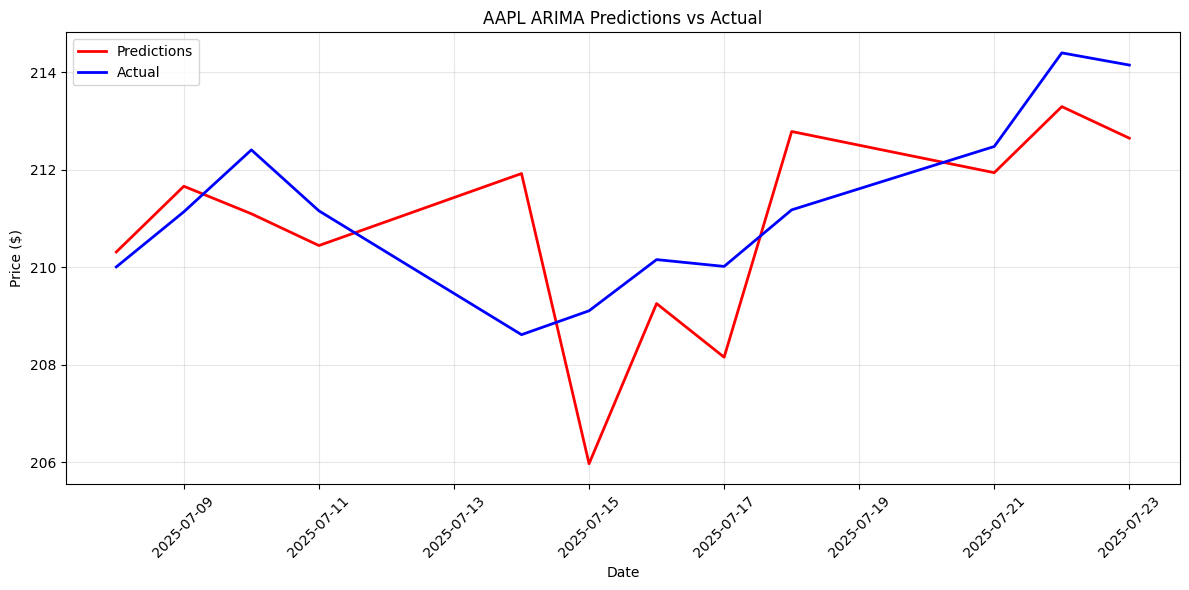

In [22]:
# Thay thế đoạn code của bạn bằng:
start = len(train)
end = len(train) + len(test) - 1  # Fix: bỏ -12

# Predictions
predictions = result.predict(start, end, typ='levels').rename("Predictions")

# Fix index alignment
predictions.index = test.index[:len(predictions)]

# Plot với matplotlib thay vì pandas plot
plt.figure(figsize=(12, 6))
plt.plot(predictions.index, predictions.values, label='Predictions', color='red', linewidth=2)
plt.plot(test.index, test.values, label='Actual', color='blue', linewidth=2)
plt.title('AAPL ARIMA Predictions vs Actual')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
